<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Import Needed Libraries</h2>
</div>

In [1]:
!pip install -q scikit-learn==1.4.2 imbalanced-learn==0.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.7/257.7 kB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [2]:
import pandas as pd
import nltk
nltk.download('punkt')
import spacy
nlp = spacy.load("en_core_web_sm")
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize , sent_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier , BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Reading Dataset And Get Info</h2>
</div>

In [3]:
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv', encoding='latin-1')

In [4]:
# Show Sample of Data
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3494,spam,Wan2 win a Meet+Greet with Westlife 4 U or a m...,NaN,NaN,NaN
3813,ham,Can. Dunno wat to get 4 her...,NaN,NaN,NaN
1509,ham,When u love someone Dont make them to love u a...,NaN,NaN,NaN
4588,ham,Have you not finished work yet or something?,NaN,NaN,NaN
3880,ham,Can you plz tell me the ans. BSLVYL sent via f...,NaN,NaN,NaN


In [5]:
# Show Shape of Data
print(f"Number of Row : {df.shape[0]}\nNumber of Columns : {df.shape[1]}")

Number of Row : 5572
Number of Columns : 5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# Check NaN Value
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
# Describe Numiric Data
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [9]:
pd.DataFrame({'Count':df.shape[0],
              'Null':df.isnull().sum(),
              'Null %':df.isnull().mean() * 100,
              'Cardinality':df.nunique()
})

,Count,Null,Null %,Cardinality
v1,5572,0,0.000000,2
v2,5572,0,0.000000,5169
Unnamed: 2,5572,5522,99.102656,43
Unnamed: 3,5572,5560,99.784637,10
Unnamed: 4,5572,5566,99.892319,5


In [10]:
# Check Dublication
df.duplicated().sum()

403

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Preprocessing Text</h2>
</div>

## Feature Engineering

In [11]:
# Drop Unncessary Columns & Dublicated Rows
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.drop_duplicates(inplace=True)
df.rename(columns={'v1':'Target', 'v2':'Text'}, inplace=True)

In [12]:
df['No_of_Characters'] = df['Text'].apply(len)
df['No_of_Words'] = df['Text'].apply(lambda x:len(word_tokenize(x)))
df['No_of_Sentences'] = df['Text'].apply(lambda x:len(sent_tokenize(x)))
df.head()

,Target,Text,No_of_Characters,No_of_Words,No_of_Sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [13]:
df.describe()

,No_of_Characters,No_of_Words,No_of_Sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [14]:
# New Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Target            5169 non-null   object
 1   Text              5169 non-null   object
 2   No_of_Characters  5169 non-null   int64 
 3   No_of_Words       5169 non-null   int64 
 4   No_of_Sentences   5169 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 242.3+ KB


<Figure size 1200x800 with 0 Axes>

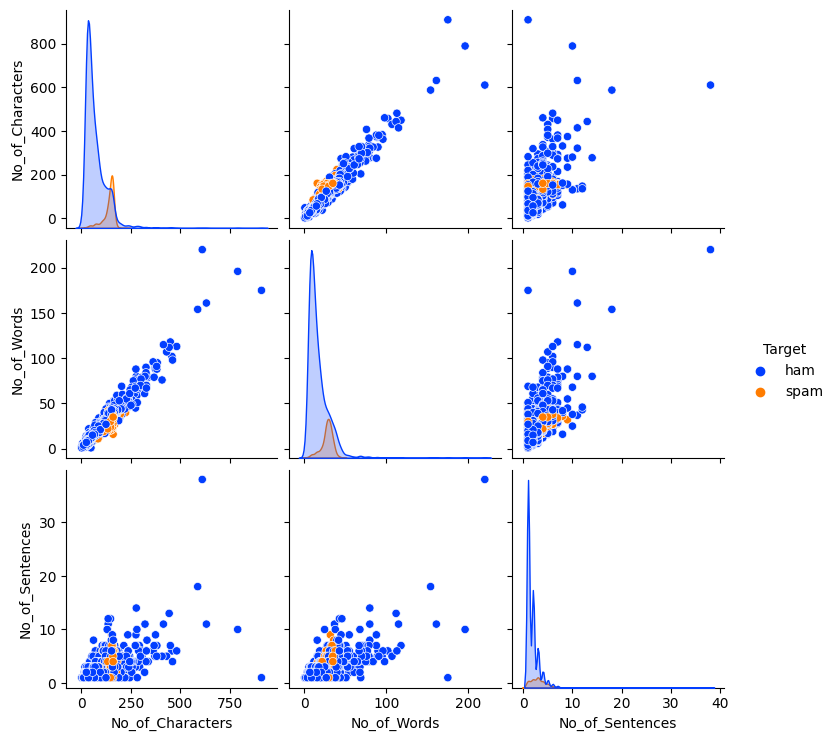

In [15]:
plt.figure(figsize=(12,8))
sns.pairplot(data=df, hue="Target",palette="bright")
plt.show()

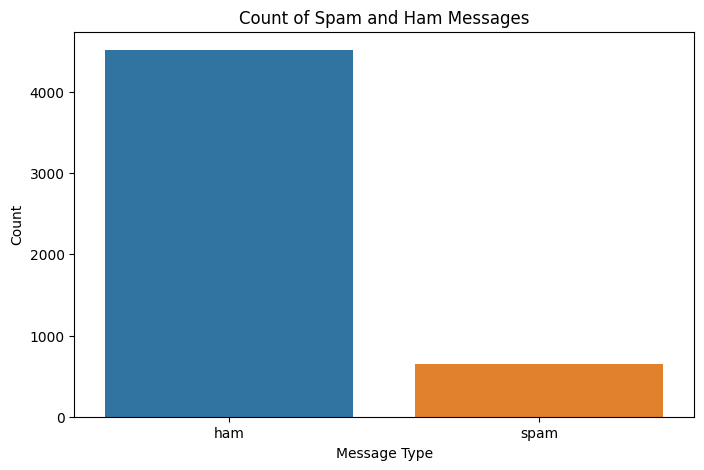

In [16]:
# plot the count of spam and ham messages
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=df)
plt.title('Count of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

- There Imbalanced Data for spam

## Clean Text

In [17]:
def clean(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    doc = nlp(' '.join(tokens))
    lemmatized = [token.lemma_ for token in doc if token.lemma_ != '-PRON-']

    return ' '.join(lemmatized)


df['cleanded_text'] = df['Text'].apply(lambda x: clean(x.lower()))

In [18]:
# Text after Cleaning
df['cleanded_text']

0       go jurong point crazy available bugis n great ...
1                                 ok lar joking wif u oni
2       free entry wkly comp win fa cup final tkts st ...
3                     u dun say early hor u c already say
4                     nah think go usf life around though
                              ...                        
5567    nd time try contact u u pound prize claim easy...
5568                               b go esplanade fr home
5569                                 pity mood suggestion
5570    guy bitching act like interested buy something...
5571                                       rofl true name
Name: cleanded_text, Length: 5169, dtype: object

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Model</h2>
</div>

In [19]:
X = df['cleanded_text']
y = df['Target'].map({'ham':0, 'spam':1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [21]:
# handle the imbalance in the dataset using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

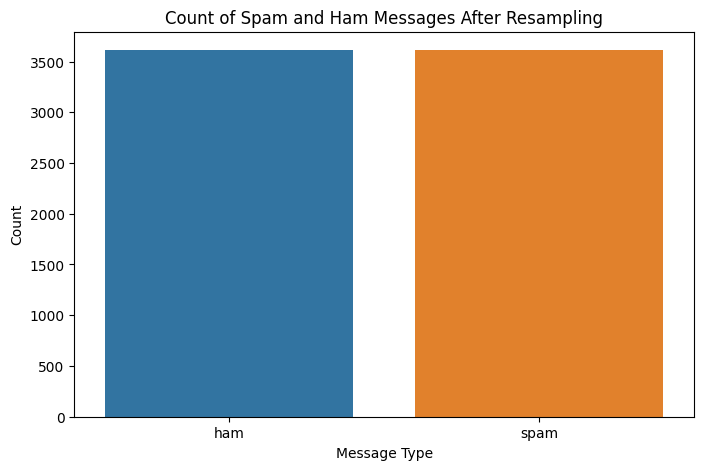

In [22]:
# plot the count of spam and ham messages
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train.map({0:'ham', 1:'spam'}))
plt.title('Count of Spam and Ham Messages After Resampling')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

In [23]:
def train(model ,model_name ,X_train ,y_train ,X_test ,y_test):
    model.fit(X_train,y_train)
    model_train_score = model.score(X_train,y_train)
    model_test_score = model.score(X_test,y_test)
    print(f"{model_name} model score on Training data: {model_train_score * 100}%\n{model_name} model score on Testing data: {model_test_score * 100}%")

def class_report(model ,X_test , y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

#### Logistic Regression

In [24]:
lr = LogisticRegression()
train(lr,"Logistic Regression", X_train, y_train, X_test, y_test)
class_report(lr, X_test, y_test)

Logistic Regression model score on Training data: 99.01743703293661%
Logistic Regression model score on Testing data: 97.48549323017409%
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.90      0.90      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.94      0.94      1034
weighted avg       0.97      0.97      0.97      1034



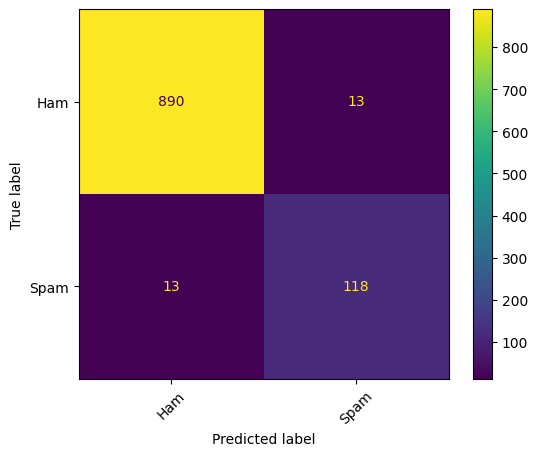

In [25]:
ConfusionMatrixDisplay.from_estimator(lr,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### KNN

In [26]:
knn = KNeighborsClassifier()
train(knn,"KNN", X_train, y_train, X_test, y_test)
class_report(knn, X_test, y_test)

KNN model score on Training data: 99.77857735953502%
KNN model score on Testing data: 95.26112185686654%
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.96      0.66      0.78       131

    accuracy                           0.95      1034
   macro avg       0.95      0.83      0.88      1034
weighted avg       0.95      0.95      0.95      1034



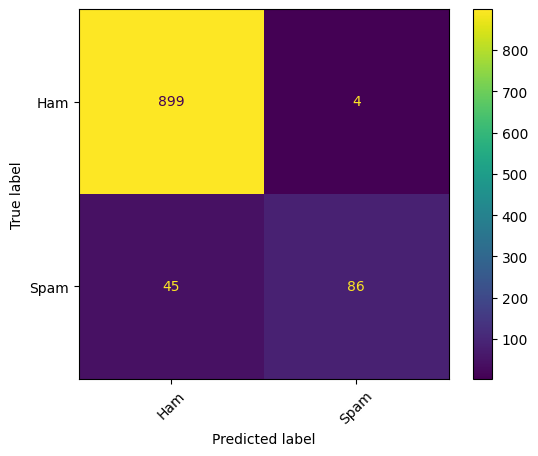

In [27]:
ConfusionMatrixDisplay.from_estimator(knn,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### Bagging

In [28]:
bagg_model = BaggingClassifier(n_estimators=40)
train(bagg_model,"Bagging", X_train, y_train, X_test, y_test)
class_report(bagg_model, X_test, y_test)

Bagging model score on Training data: 99.98616108497093%
Bagging model score on Testing data: 94.58413926499033%
              precision    recall  f1-score   support

         Ham       0.98      0.96      0.97       903
        Spam       0.76      0.84      0.80       131

    accuracy                           0.95      1034
   macro avg       0.87      0.90      0.88      1034
weighted avg       0.95      0.95      0.95      1034



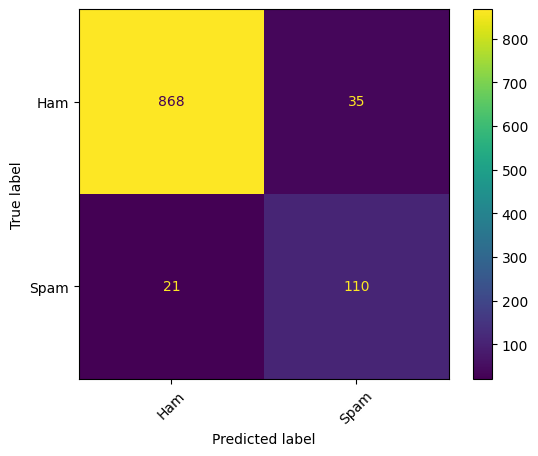

In [29]:
ConfusionMatrixDisplay.from_estimator(bagg_model,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### Gradient Boosting

In [30]:
gb_model = GradientBoostingClassifier(n_estimators=50)
train(gb_model,"Boosting", X_train, y_train, X_test, y_test)
class_report(gb_model, X_test, y_test)

Boosting model score on Training data: 96.8170495433158%
Boosting model score on Testing data: 93.32688588007737%
              precision    recall  f1-score   support

         Ham       0.97      0.95      0.96       903
        Spam       0.70      0.83      0.76       131

    accuracy                           0.93      1034
   macro avg       0.84      0.89      0.86      1034
weighted avg       0.94      0.93      0.94      1034



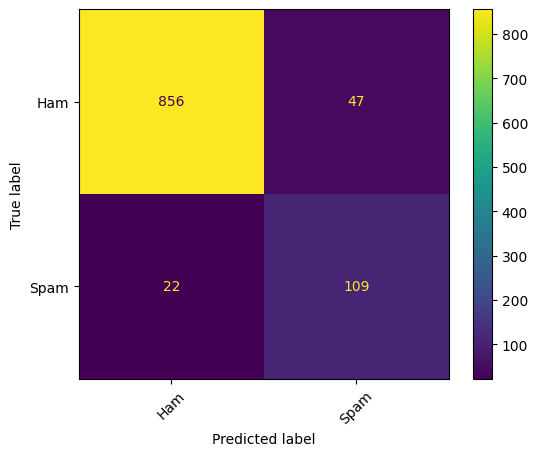

In [31]:
ConfusionMatrixDisplay.from_estimator(gb_model,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### Xgboost

In [32]:
xgboost = model = XGBClassifier(objective = "binary:logistic" , subsample = 0.7 , min_child_weight = 3,
                                max_depth = 3 , learning_rate = 0.1 , gamma = 0 , colsample_bytree = 0.5,)
train(xgboost,"Xgboost", X_train, y_train, X_test, y_test)
class_report(xgboost, X_test, y_test)

Xgboost model score on Training data: 97.67506227511763%
Xgboost model score on Testing data: 94.68085106382979%
              precision    recall  f1-score   support

         Ham       0.97      0.96      0.97       903
        Spam       0.77      0.82      0.80       131

    accuracy                           0.95      1034
   macro avg       0.87      0.89      0.88      1034
weighted avg       0.95      0.95      0.95      1034



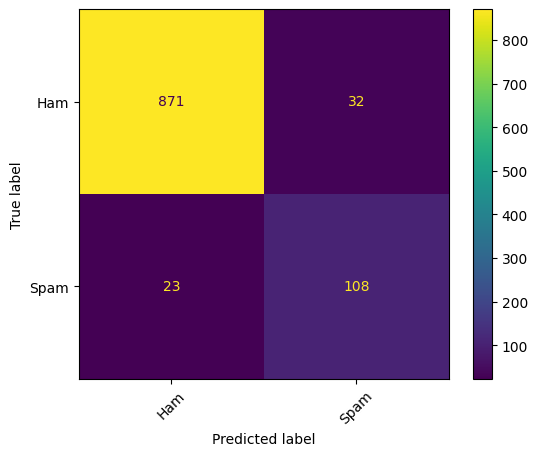

In [33]:
ConfusionMatrixDisplay.from_estimator(xgboost,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );